# Severe weather soundings

```{image} ../thumbnails/sounderpy_logo.png
:alt: Sounderpy logo
:width: 150px
:height: 100px
```

---

## Overview

Upper-air soundings give insight into the thermodynamic and kinematic structure of the atmosphere—information that directly shapes how thunderstorms develop, intensify, or fail. In this notebook, we use **SounderPy** to access and visualize both **observed IGRA2 soundings** and **model-derived (reanalysis) soundings** for the northeastern United States. By comparing these profiles, we explore how the environment influences convective potential and storm behavior, especially in terrain-influenced regions such as Albany, NY.

This notebook is organized into the following sections:

1. **Import required packages**  
2. **Retrieve observed and reanalysis sounding data**  
3. **Compute key thermodynamic indicators (CAPE, LCL, etc.)**  
4. **Compute kinematic indicators (shear, SRH, wind profiles)**  
5. **Visualize sounding structure**


## Prerequisites

This notebook assumes that the reader has some prior exposure to basic atmospheric thermodynamics and Python-based data analysis.  
It builds directly on foundational concepts such as interpreting sounding profiles, understanding convective parameters, and working with geospatial data formats.  
The table below outlines the prerequisite concepts and their relative importance.

| Concepts | Importance | Notes |
|-----------|-------------|-------|
| **Intro to Soundings and Thermodynamics** | Necessary | Familiarity with pressure–temperature diagrams, CAPE/CIN, and LCL/LFC concepts will help interpret the results. |
| **Intro to SounderPy** | Necessary | SounderPy is the core tool used for data access, processing, and plotting of upper-air soundings. See the [SounderPy GitHub](https://github.com/kylejgillett/sounderpy). |
| **Understanding of NetCDF and IGRA2 data** | Helpful | Basic knowledge of how radiosonde datasets and metadata are structured. |
| **Intro to Matplotlib** | Helpful | Needed to understand the plotting functions for Skew-T diagrams.|



- **Time to learn**: ≈ 30–40 minutes  
(*about 5–10 minutes per subsection depending on familiarity*)





---

## Imports

In [1]:
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import sounderpy as spy
import matplotlib.pyplot as plt
from IPython.display import display
from siphon.simplewebservice.igra2 import IGRAUpperAir


## ---------------------------------- SOUNDERPY ----------------------------------- ##
##          Vertical Profile Data Retrieval and Analysis Tool For Python            ##
##                    v3.0.9 | August 2025 | (C) Kyle J Gillett                     ##
##                 Docs: https://kylejgillett.github.io/sounderpy/                  ##
## --------------------- THANK YOU FOR USING THIS PACKAGE! ------------------------ ##



## Data Retrieval

### Data sources 

SounderPy can pull upper-air sounding profiles directly from the **NOAA IGRA2 archive** or from the **University of Wyoming** radiosonde database. Both sources contain temperature, humidity, and wind observations collected by weather balloons launched around the world.

- **IGRAv2 (Integrated Global Radiosonde Archive, Version 2)** - a NOAA resource that provides globally standardized sounding data, including historical and recent observations.  
- **Wyoming Upper-Air Archive** - a widely used real-time source for current and recent radiosonde launches from National Weather Service and international stations.

Notes on Observed Soundings

- Routine balloon launches occur twice daily at **00 UTC** and **12 UTC**, with additional launches possible during special weather events.  
- Because these are direct measurements, some records may be **incomplete, missing, or contain minor errors**.  
- SounderPy helps manage these issues by automatically cleaning and structuring the retrieved data for analysis.

Next, we’ll fetch required dataset from IGRA2 (or Wyoming, depending on availability) to examine soundings.

### Request observed data

Use Siphon's `IGRAUpperAir` interface to request a specific radiosonde sounding from NOAA's IGRA2 archive.

- `date`: specifies the observation time (UTC). 
- `station`: WMO station identifier. `'USM00072518'` corresponds to the Albany, NY radiosonde site.
- `IGRAUpperAir.request_data()`: downloads both the sounding data (`df`) and associated header metadata (`header`) for the specified date and station.

This returns:
- `df`: a Pandas DataFrame containing the vertical profile (pressure, temperature, dew point, wind, etc.).
- `header`: a dictionary of station metadata and observation context.



In [2]:
# Albany
date, station = datetime(2014, 5, 23, 00), "USM00072518" # 5/22/14 1900hrs - Albany, NY
df, header = IGRAUpperAir.request_data(date, station)



### Examine the datasets

In [3]:
df.head(3)

,lvltyp1,lvltyp2,etime,pressure,pflag,height,zflag,temperature,tflag,relative_humidity,direction,speed,date,u_wind,v_wind,dewpoint
0,2,1,0,999.14,2,95,0,15.4,2,85.0,192,2.6,2014-05-23,0.5,2.5,12.9
1,2,0,11,991.28,0,162,2,14.6,2,87.3,182,4.6,2014-05-23,0.2,4.6,12.5
2,2,0,111,932.09,0,680,2,11.1,2,94.7,167,7.1,2014-05-23,-1.6,6.9,10.3


## Thermodynamic & Kinematic Parameters

Load the observed data and store it in a variable. We add our parameters defined above into the tool below

In [4]:
def get_obs_by_datetime(station, dt):
    return spy.get_obs_data(station, f"{dt:%Y}", f"{dt:%m}", f"{dt:%d}", f"{dt:%H}")

obs_data = get_obs_by_datetime(station, date)

> OBSERVED DATA ACCESS FUNCTION
  -----------------------------------
    > PROFILE FOUND: USM00072518 on 05/23/2014 at 00z | From IGRAv2
    > COMPLETE --------
    > RUNTIME: 00:00:07
    > SUMMARY: 00Z Launch for USM00072518, ALBANY at 05-23-2014-00Z
 
    > THERMODYNAMICS --------------------------------------------- 
    --- SBCAPE: 31.2 | MUCAPE: 65.7 | MLCAPE: 9.1 | MUECAPE: --
    --- MU 0-3: 0.1 | MU 0-6: 65.7 | SB 0-3: 0.0 | SB 0-6: 31.2
 
    > KINEMATICS ------------------------------------------------- 
    --- 0-500 SRW: 28.4 knot | 0-500 SWV: 0.003 | 0-500 SHEAR: 8.6 | 0-500 SRH: -20.3
    --- 1-3km SRW: 19.6 knot | 1-3km SWV: 0.005 | 1-3km SHEAR: 24.0 | | 1-3km SRH: 29.0
 


### Examine observed data 

In [5]:
obs_data

{'p': <Quantity([999.14 991.28 932.09 925.   920.3  912.41 850.   845.23 837.87 783.47
  759.21 741.43 729.82 717.53 704.53 700.   687.18 647.12 631.48 628.52
  621.85 600.47 568.13 557.08 548.29 540.33 532.29 526.61 520.32 510.18
  502.96 500.   497.11 495.06 490.68 486.94 478.01 464.25 460.59 449.9
  431.82 400.   393.19 380.98 369.07 358.81 321.7  300.   293.63 276.9
  258.03 250.86 250.   242.52 234.17 231.54 213.73 204.03 200.   197.2
  188.43 174.87 165.6  162.07 151.75 150.   145.13 139.62 133.58 128.78
  126.2  113.84 107.4  100.    93.96  89.92  85.08  80.76  70.99  70.
   65.73  59.7   52.92  50.    44.45  40.08  30.    26.28  25.51  23.19
   21.89  20.48  20.    18.77  17.56  16.15  14.86  11.76  10.76  10.
    9.28   9.     8.     7.96], 'hectopascal')>,
 'z': <Quantity([   95   162   680   744   787   859  1451  1498  1571  2123  2379  2571
   2698  2835  2981  3032  3180  3653  3844  3881  3964  4235  4660  4810
   4930  5041  5155  5236  5326  5474  5580  5624  5668  569


### Load the RAP reanalysis data and store it in a variable.

In [6]:
reanl_data = spy.get_model_data('rap', [42.69, -73.83], '2014', '05', '22', '18', )

> RAP REANALYSIS DATA ACCESS FUNCTION
  -----------------------------------------
    > DATASET USED: RAP_25km_anl_old
    > COMPLETE --------
    > RUNTIME: 00:00:06
    > SUMMARY: 18Z RAP F00 for[42.69, -73.83] at 05-22-2014-18Z
 
    > THERMODYNAMICS --------------------------------------------- 
    --- SBCAPE: 1492.5 | MUCAPE: 1492.5 | MLCAPE: 1025.6 | MUECAPE: 1214.3
    --- MU 0-3: 244.5 | MU 0-6: 796.5 | SB 0-3: 244.5 | SB 0-6: 796.5
 
    > KINEMATICS ------------------------------------------------- 
    --- 0-500 SRW: 24.8 knot | 0-500 SWV: 0.001 | 0-500 SHEAR: 1.1 | 0-500 SRH: -7.0
    --- 1-3km SRW: 17.7 knot | 1-3km SWV: 0.004 | 1-3km SHEAR: 19.3 | | 1-3km SRH: 55.5
 


### Examine RAP reanalysis data 

In [7]:
reanl_data

{'T': <Quantity([ 19.15615234  15.44032182  12.86366918  10.80825016   9.54243181
    8.63067136   7.5522462    6.3547107    4.94147789   3.15899689
    1.18582725  -0.7312156   -2.48860733  -4.07556003  -5.49704089
   -6.78125445  -8.24243964  -9.83085073 -11.5520797  -13.43450324
  -15.44607526 -17.46092017 -19.46971967 -21.47299981 -23.42907183
  -25.34714356 -27.29292349 -29.26692242 -31.29741154 -33.28842266
  -35.25377496 -37.15059568 -39.03018469 -40.82785216 -42.61597739
  -44.24743269 -45.85795907 -47.00917154 -47.99989338 -48.70397255
  -49.04839773 -49.39282291 -49.56918405 -49.73578132 -49.95419463
  -50.39384471 -50.83349479 -51.26333005 -51.62237595 -51.98142186
  -52.34046777 -52.73352005 -53.14375509 -53.55399012 -53.96422516
  -54.32233776 -54.65788043 -54.9934231  -55.32896577 -55.65721926
  -55.80974599 -55.96227271 -56.11479944 -56.26732617 -56.41985289], 'degree_Celsius')>,
 'Td': <Quantity([ 15.26831467  13.69555534  12.26299613  10.56038599   9.12608199
    6.791

### Change the default plot titles

In [8]:
#Observed data titles
obs_data["site_info"]["source"] = "IGRAv2 OBSERVED PROFILE"
obs_data["titles"]["top_title"] = "IGRAv2 OBSERVED VERTICAL PROFILE"

#Reanalysis data titles
reanl_data["site_info"]["site-name"] = "ALBANY, NY"
reanl_data["titles"]["right_title"] = "ALBANY, NY | 42.69, -73.83"


## Visualize soundings  

### Observed sounding 

> SOUNDING PLOTTER FUNCTION
  ---------------------------------
- no radar data available -


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


    > COMPLETE --------
    > RUNTIME: 00:00:02


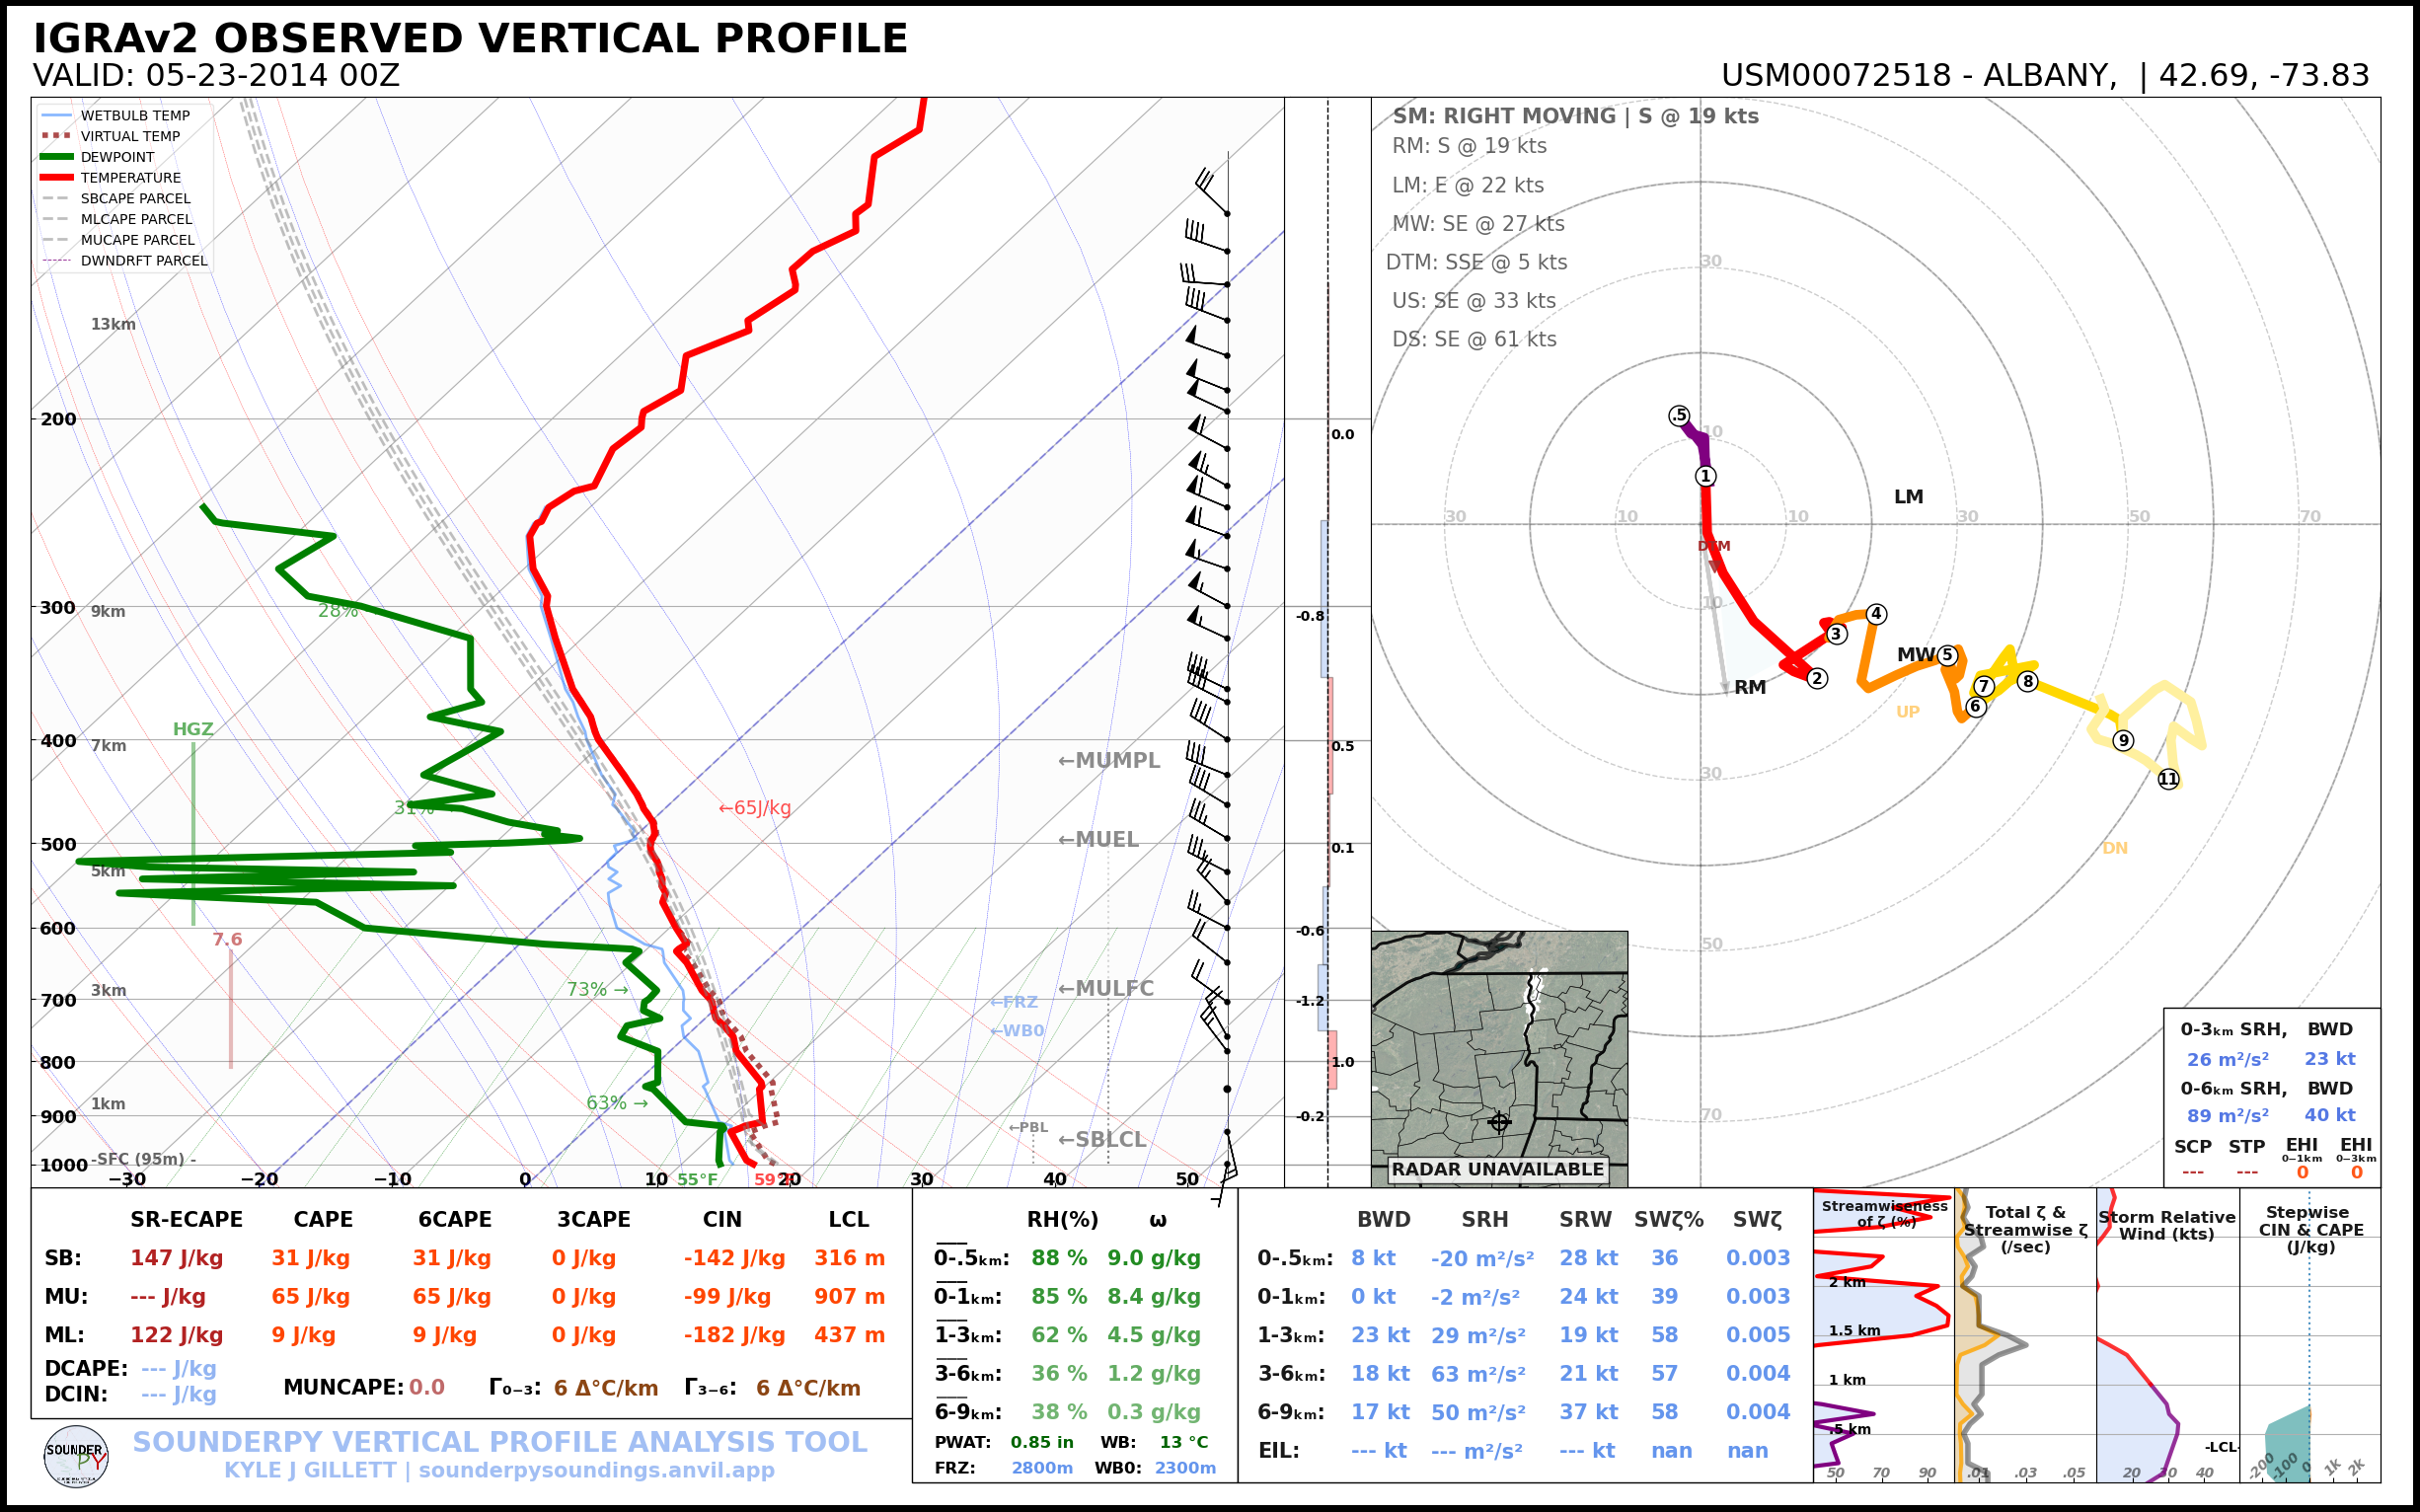

In [9]:
# STEP 1 - Simply add our `model_data` variable to SounderPy's plot tool
# we can also declare a few settings and add them to the tool.

style       = 'full' # try changing to... 'simple'
dark_mode   = False  # try changing to.... True
color_blind = False # try changing to.... True

spy.build_sounding(obs_data, style, color_blind, dark_mode)

# you can 'right-click' the image below to open it in a new tab or to save it
# to your device!

### Reanalysis Sounding

> SOUNDING PLOTTER FUNCTION
  ---------------------------------
- no radar data available -


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


    > COMPLETE --------
    > RUNTIME: 00:00:11


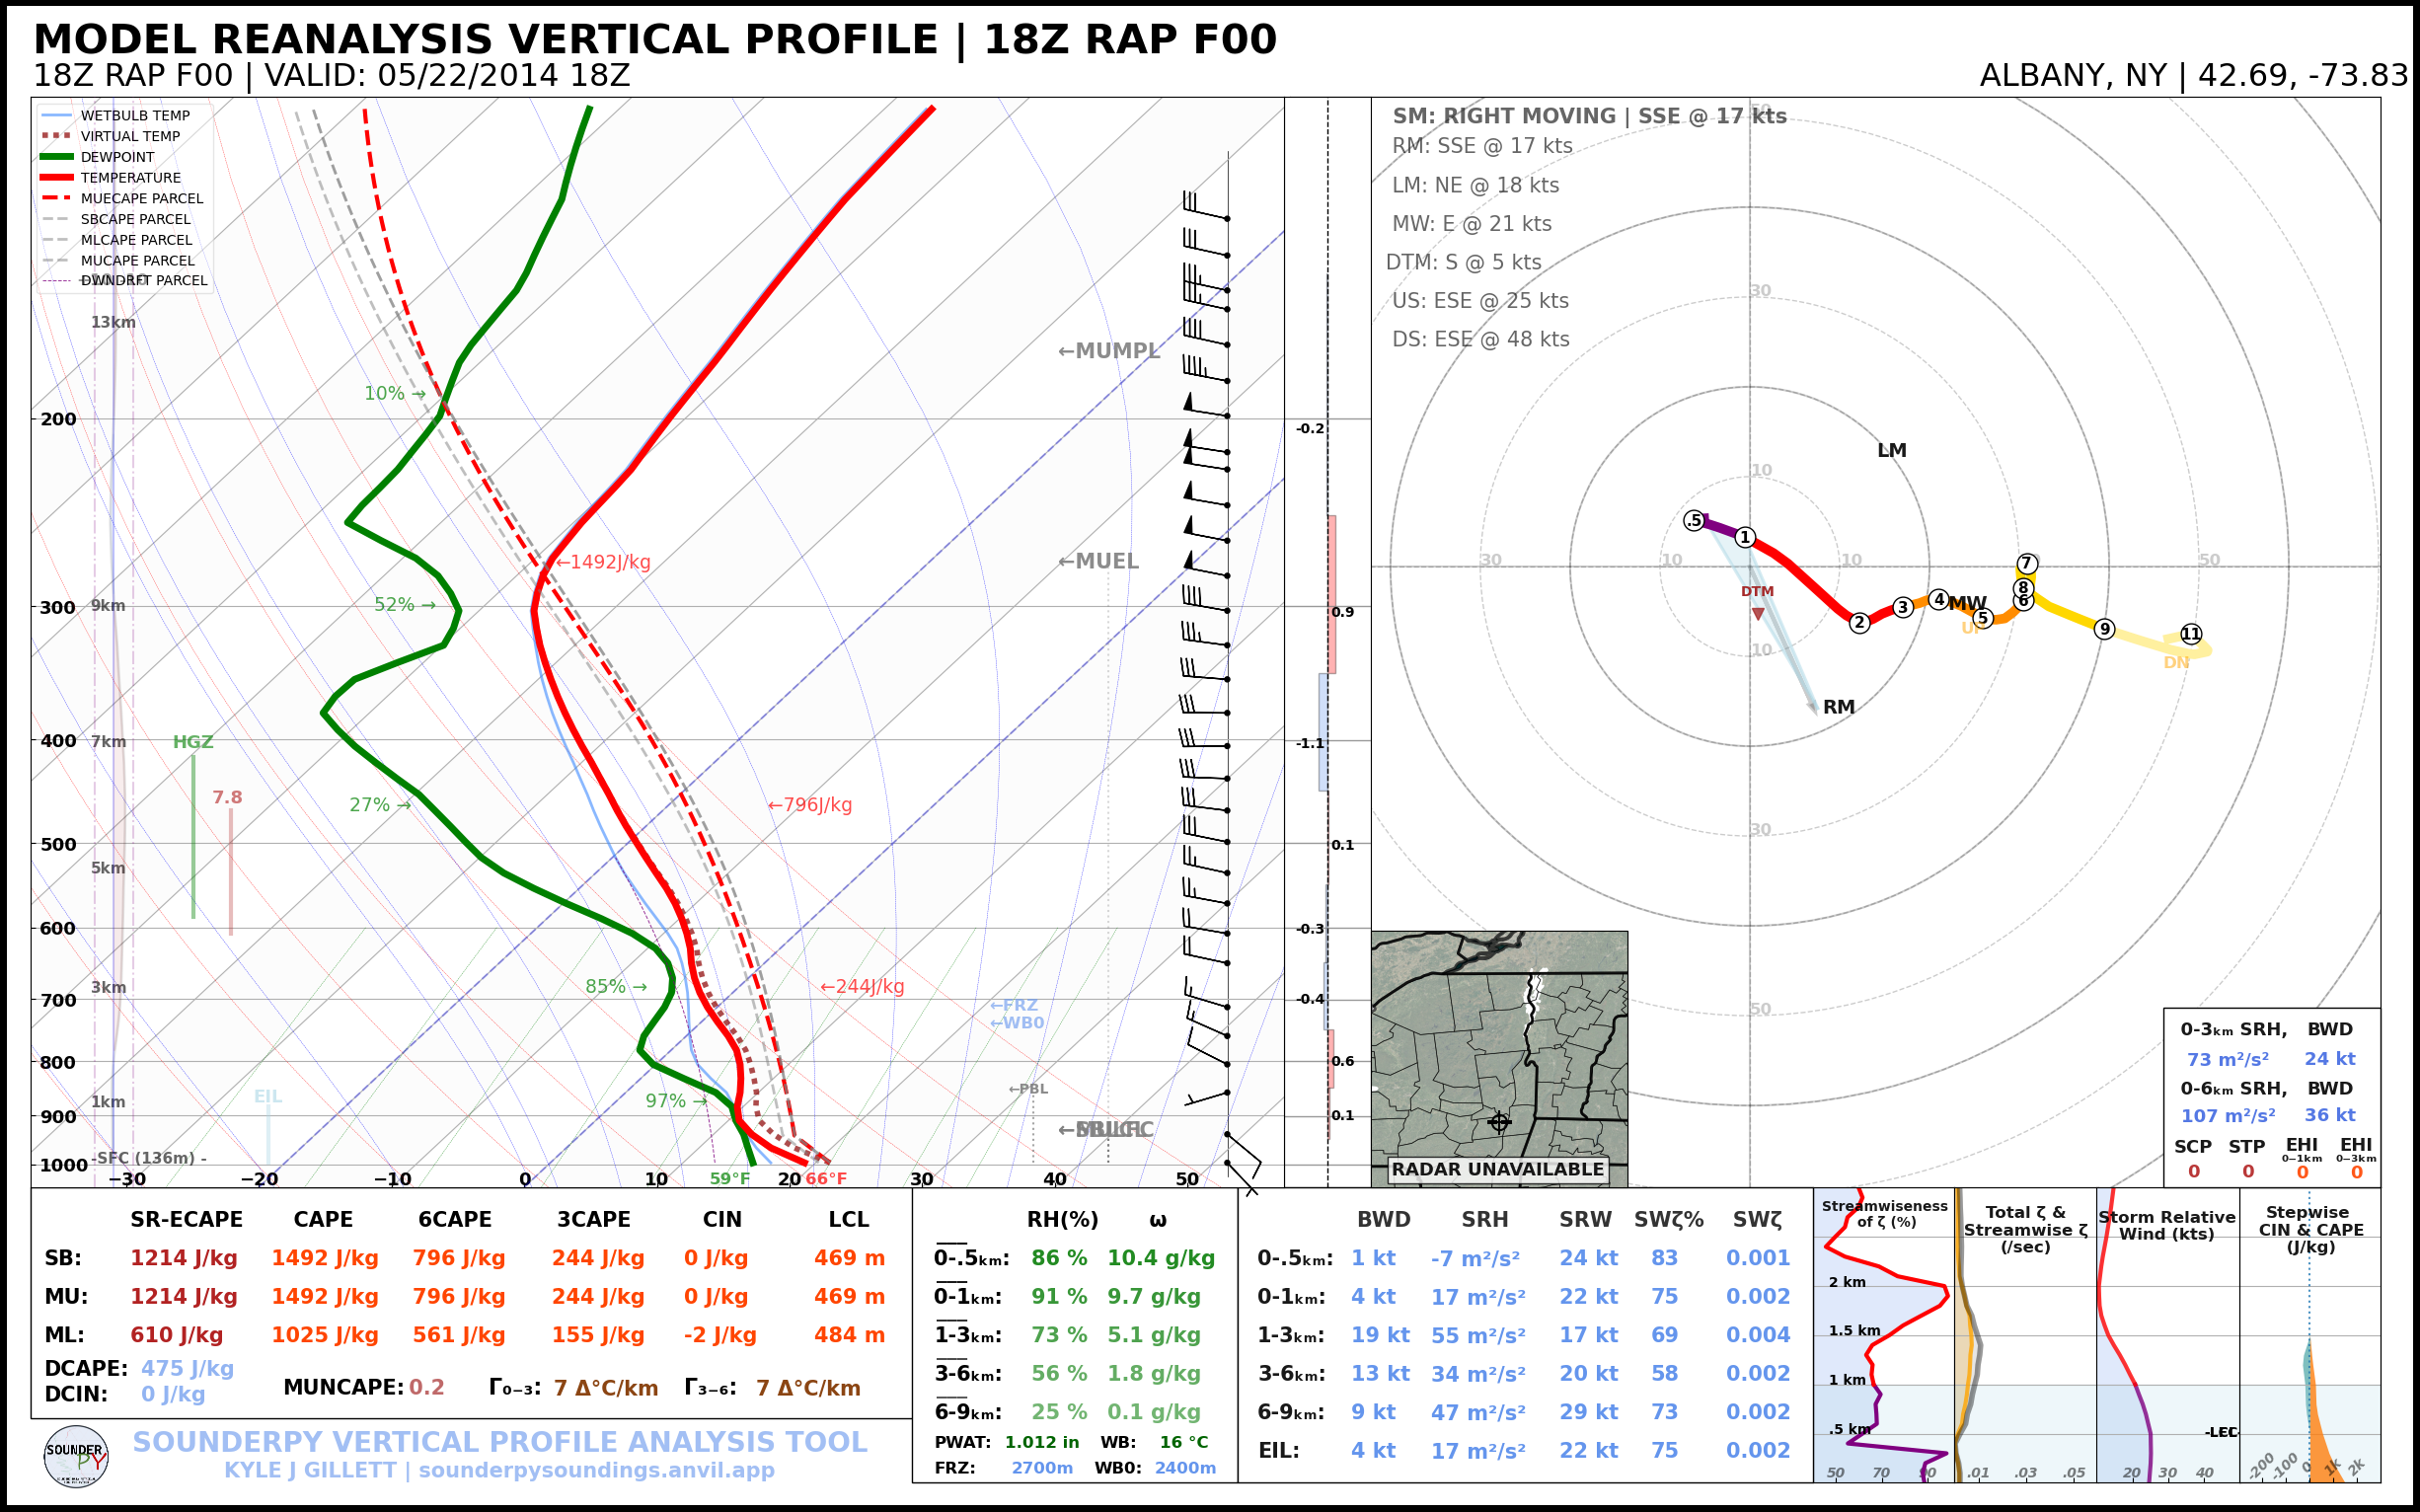

In [10]:
spy.build_sounding(reanl_data, style, color_blind, dark_mode)

---

## Summary

In this notebook, we explored how SounderPy can be used to retrieve, process, and visualize both observed IGRA2 soundings and model based reanalysis profiles for the northeastern United States. By examining thermodynamic indicators such as CAPE, LCL, and lapse rates alongside kinematic factors like shear and storm relative winds, we developed a clearer picture of how the vertical structure of the atmosphere influences convective potential. The comparison between observed and model derived profiles also highlighted how reanalysis data can complement real-world observations, especially when investigating storm environments over complex terrain.


## Resources and references

This notebook uses open-source atmospheric science tools and publicly available datasets. The following references document the libraries, datasets, and examples that informed this work.

Python Libraries and Documentation
- **SounderPy**: Gillett, K. (2023). *SounderPy: A Python package for upper-air sounding analysis*. GitHub repository.  
  https://github.com/kylejgillett/sounderpy  
  Beginner’s Cookbook used for guidance:  
  https://github.com/kylejgillett/sounderpy/blob/main/colab_tutorials/beginners_sounderpy_cookbook.ipynb

Data Sources
- **RAP (Rapid Refresh) Reanalysis**: NOAA Earth System Research Laboratory (ESRL).  
  Dataset access via ESRL and NCEP model archives.  
  https://rapidrefresh.noaa.gov/

- **IGRA2 Radiosonde Archive** (if used for comparison):  
  https://www.ncei.noaa.gov/products/weather-balloon/integrated-global-radiosonde-archive

- **Definitions & Computations of Severe Weather Parameters**  
  National Weather Service Louisville (NWS LMK).  
  https://www.weather.gov/media/lmk/soo/svr_parameters.pdf

